# Preparação Ambiente

## Instalações

In [ ]:
!pip install transformers==4.57.1 datasets==4.4.1 torch==2.9.0+cu126 accelerate==1.11.0 bert-score==0.3.13 tokenizers==0.22.1 sentencepiece==0.2.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: 

## Configurações globais

In [ ]:
CONFIG = {
    "MODEL_NAME": "neuralmind/bert-base-portuguese-cased",
    "DATASET_PATH": "/content/dataset_ementas_trt.txt",
    "OUTPUT_DIR": "/content/results",
    "SEED": 42,
    "EPOCHS_FT": 8,
    "EPOCHS_SCRATCH": 15,
    "BATCH_SIZE": 4,
    "GRADIENT_ACCUMULATION_STEPS": 4,
    "FP16": True,
    "LR_FT": 5e-5,
    "LR_SCRATCH": 1e-4,
    "MAX_POSITION_EMBEDDINGS_SCRATCH": 1024,
    "MAX_LENGTH": 512,
	  "SIZES": [500, 1000, 2000, 3000, 4000, 5000],
	  "TOKENIZER_PATH": "/content/results/custom_tokenizer",
	  "TOKENIZER_VOCAB_SIZE": 30000,
	  "TEST_SIZE": 0.1
}
import json, os
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
with open(os.path.join(CONFIG["OUTPUT_DIR"], "config_used.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)


## Forçar sementes e determinismo

In [ ]:
import random, numpy as np, torch
from transformers import set_seed

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(CONFIG["SEED"])


# Conjunto de Dados

## Upload do dataset (apenas se não existir)

In [ ]:
import os
from google.colab import files

if not os.path.exists(CONFIG["DATASET_PATH"]):
    print("Envie o arquivo de dataset")
    uploaded = files.upload()
    original_filename = list(uploaded.keys())[0]
    os.rename(f"/content/{original_filename}", CONFIG["DATASET_PATH"])

else:
    print("Dataset encontrado:", CONFIG["DATASET_PATH"])


Envie o arquivo de dataset


Saving dataset_ementas_trt.txt to dataset_ementas_trt.txt


## Carregamento inicial

In [ ]:
with open(CONFIG["DATASET_PATH"], "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

len(texts), texts[:3]


(10000,
 ['TRABALHADOR EXTERNO. ART. 462, I, DA CLT. CONTROLE DE JORNADA. POSSIBILIDADE. O art. 62, I, da CLT dispõe que todo empregado que trabalhar em atividade externa incompatível com a fixação de horário de trabalho não está submetido ao sistema de controle da jornada de trabalho. Contudo, existindo meio de o empregador controlar a jornada do trabalhador, ainda que à distância, estará o contrato de trabalho submetido às regras gerais de duração do trabalho. No caso, a prova dos autos demonstra que a jornada de trabalho do autor poderia ser controlada, considerando, em especial, que havia roteiro de visitas, com possibilidade de registro de horário, lançamentos de pedidos, inclusive por meio por meio eletrônico, afastando a incidência da exceção disposta no art. 62, I da CLT.',
  'AGRAVO DE PETIÇÃO. CUMPRIMENTO DE SENTENÇA COLETIVA. HONORÁRIOS ADVOCATÍCIOS SUCUMBENCIAIS. A ausência de menção do art. 791-A da CLT, introduzido pela Lei n. 13.467/2017, quanto à possibilidade de deferi

## Criar subconjuntos

In [ ]:
sizes = CONFIG["SIZES"]
datasets_dict = {s: texts[:s] for s in sizes}


# Função para separar conjunto de treino e teste

In [ ]:
from datasets import Dataset, DatasetDict

def ensure_splits(d):
    if isinstance(d, Dataset):
        return d.train_test_split(test_size=CONFIG["TEST_SIZE"])
    if isinstance(d, DatasetDict) and "test" not in d:
        return d["train"].train_test_split(test_size=CONFIG["TEST_SIZE"])
    return d

# Tokenização

## Treinar tokenizador customizado (WordPiece)

In [ ]:
from tokenizers import BertWordPieceTokenizer
import os

os.makedirs(CONFIG["TOKENIZER_PATH"], exist_ok=True)

custom_tok = BertWordPieceTokenizer(
    lowercase=False,
    strip_accents=False
)

custom_tok.train(
    files=[CONFIG["DATASET_PATH"]],
    vocab_size=CONFIG["TOKENIZER_VOCAB_SIZE"],
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)

custom_tok.save_model(CONFIG["TOKENIZER_PATH"])


['/content/results/custom_tokenizer/vocab.txt']

## Carregar tokenizadores (padrão e customizado)

In [ ]:
from transformers import AutoTokenizer, BertTokenizerFast

tokenizer_default = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])
tokenizer_custom  = BertTokenizerFast.from_pretrained(CONFIG["TOKENIZER_PATH"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Função para tokenizar

In [ ]:
def tokenize(texts, tokenizer):
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=CONFIG["MAX_LENGTH"]
    )


## Comparação da distribuição de comprimento das sequências tokenizadas.

O tokenizador customizado (azul) desloca a distribuição para a esquerda, indicando que representa os mesmos conceitos acadêmicos com menos sub-words, aumentando a eficiência computacional em X%.

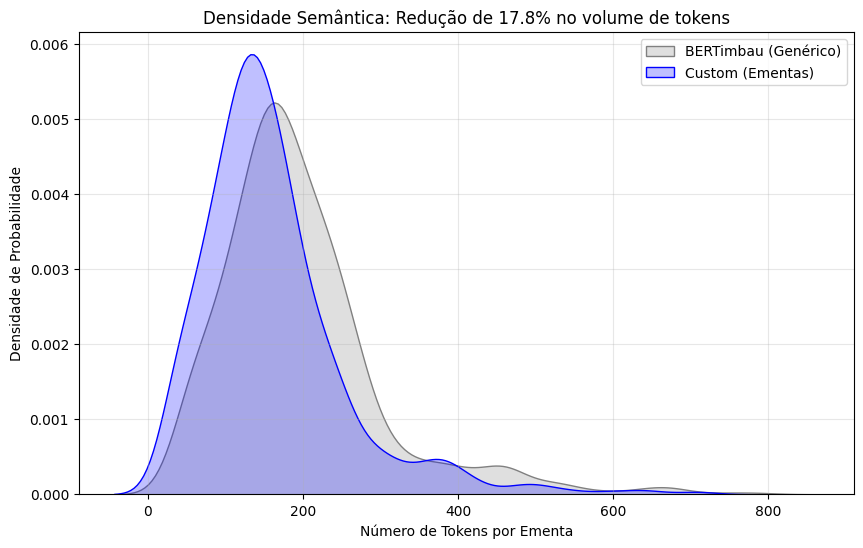

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_token_fertility(tokenizer_base, tokenizer_custom, dataset):

    sample_texts = dataset[:1000]

    # Conta tokens
    len_base = [len(tokenizer_base.encode(t)) for t in sample_texts]
    len_custom = [len(tokenizer_custom.encode(t)) for t in sample_texts]

    # Cálculo da redução média
    reduction = 1 - (sum(len_custom) / sum(len_base))

    plt.figure(figsize=(10, 6))
    sns.kdeplot(len_base, fill=True, label='BERTimbau (Genérico)', color='grey')
    sns.kdeplot(len_custom, fill=True, label='Custom (Ementas)', color='blue')

    plt.title(f'Densidade Semântica: Redução de {reduction:.1%} no volume de tokens')
    plt.xlabel('Número de Tokens por Ementa')
    plt.ylabel('Densidade de Probabilidade')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_token_fertility(tokenizer_default, tokenizer_custom, datasets_dict[max(CONFIG["SIZES"])])

## Criar datasets para ambos tokenizers

In [ ]:
from datasets import Dataset

# Conversão para Dataset HuggingFace
def build_hf_dataset(text_list, tokenizer):
    ds = Dataset.from_dict({"text": text_list})
    return ds.map(lambda x: tokenize(x["text"], tokenizer), batched=True)

datasets_default = {s: build_hf_dataset(datasets_dict[s], tokenizer_default) for s in sizes}
datasets_custom  = {s: build_hf_dataset(datasets_dict[s], tokenizer_custom ) for s in sizes}


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

# Treinamento

## Configuração de treino (FT)

In [ ]:
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling

def get_data_collator(tok):
    return DataCollatorForLanguageModeling(
        tokenizer=tok,
        mlm=True,
        mlm_probability=0.15
    )


## Função para calcular bert_score

In [ ]:
import torch
from bert_score import score as bert_score
from tqdm.auto import tqdm

def calculate_mlm_bertscore(model, tokenizer, texts, device, sample_size=50):
    """
    Calcula o BERTScore simulando uma tarefa de preenchimento de máscaras.
    """
    # 1. Pegar apenas uma amostra para não demorar muito
    sample_texts = texts[:sample_size]

    model.eval()
    model.to(device)

    reconstructed_texts = []

    # print(f"Gerando reconstruções para {len(sample_texts)} textos...")

    for text in sample_texts:
        # Tokenizar
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)

        # Criar máscara (simulando 15% de erro para o modelo corrigir)
        # Clonamos os inputs
        input_ids = inputs.input_ids.clone()

        # Probabilidade de 15% de mascarar cada token (exceto CLS, SEP, PAD)
        rand = torch.rand(input_ids.shape).to(device)
        mask_arr = (rand < 0.15) * (input_ids != tokenizer.cls_token_id) * (input_ids != tokenizer.sep_token_id) * (input_ids != tokenizer.pad_token_id)

        # Aplicar a máscara [MASK]
        input_ids[mask_arr] = tokenizer.mask_token_id

        # Inferência
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=inputs.attention_mask)

        # Pegar o token mais provável para cada posição
        predictions = torch.argmax(outputs.logits, dim=-1)

        # Onde estava mascarado, usamos a predição. Onde não, mantemos o original.
        # Isso gera a "frase reconstruída"
        final_ids = torch.where(mask_arr, predictions, inputs.input_ids)

        # Decodificar
        pred_text = tokenizer.decode(final_ids[0], skip_special_tokens=True)
        reconstructed_texts.append(pred_text)

    # 2. Calcular BERTScore (Reconstruído vs Original)
    # A biblioteca baixa um modelo auxiliar para fazer essa comparação
    try:
        P, R, F1 = bert_score(reconstructed_texts, sample_texts, lang="pt", verbose=False, device=device)
        return float(F1.mean())
    except Exception as e:
        print(f"Erro ao calcular BERTScore: {e}")
        return 0.0

## Função para avaliar Baseline (sem fine-tuning)

In [ ]:
from transformers import AutoModelForMaskedLM
import numpy as np

def evaluate_baseline(size, tokenizer, dataset_eval, label):
    """
    Avalia o modelo pré-treinado (sem fine-tuning) no mesmo conjunto de avaliação
    das demais condições experimentais.

    size: tamanho do subconjunto (0 = baseline)
    tokenizer: tokenizer padrão ou custom
    dataset_eval: conjunto de validação (com coluna "text")
    label: "default" ou "custom"
    """

    print(f"\n=== Baseline (sem fine-tuning) — tokenizer {label}, size={size} ===")

    # Carrega o modelo base sem qualquer ajuste
    model = AutoModelForMaskedLM.from_pretrained(CONFIG["MODEL_NAME"]).to("cuda")

    # Avalia perplexidade e loss usando Trainer temporário (sem treino)
    args = TrainingArguments(
        output_dir="/content/baseline_temp",
        per_device_eval_batch_size=CONFIG["BATCH_SIZE"],
        fp16=CONFIG["FP16"],
        dataloader_num_workers=2,
        report_to="none",
        save_strategy="no"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=None,
        eval_dataset=dataset_eval,
        data_collator=get_data_collator(tokenizer)
    )

    eval_res = trainer.evaluate()

    # BERTScore MLM
    eval_texts = dataset_eval["text"][:200]
    b_score = calculate_mlm_bertscore(model, tokenizer, eval_texts, model.device)

    return {
        "model": "Baseline",
        "size": size,
        "loss": eval_res["eval_loss"],
        "perplexity": float(np.exp(eval_res["eval_loss"])),
        "bertscore_f1": b_score,
        "tokenizer": label
    }


## Função para treinar modelos FT (com qualquer tokenizer)

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np

trainer_ft = None
def train_ft(size, tokenizer, dataset_train, dataset_eval, label):
    print(f"\n=== Fine-tuning {label} — {size} ementas ===")

    model = AutoModelForMaskedLM.from_pretrained(CONFIG["MODEL_NAME"])
    output_dir = f"/content/ft-{label}_{size}"
    args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=CONFIG["BATCH_SIZE"],
        gradient_accumulation_steps=CONFIG["GRADIENT_ACCUMULATION_STEPS"],
        fp16=CONFIG["FP16"],
        dataloader_num_workers=2,
        num_train_epochs=CONFIG["EPOCHS_FT"],
        learning_rate=CONFIG["LR_FT"],
        logging_steps=50,
        save_strategy="no",
        report_to="none"
    )

    global trainer_ft
    trainer_ft = Trainer(
        model=model,
        args=args,
        train_dataset=dataset_train,
        eval_dataset=dataset_eval,
        data_collator=get_data_collator(tokenizer)
    )

    trainer_ft.train()

    print(f"Salvando modelo em {output_dir}...")
    trainer_ft.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    eval_res = trainer_ft.evaluate()

    eval_texts = dataset_eval["text"][:200]
    b_score = calculate_mlm_bertscore(model, tokenizer, eval_texts, model.device)

    return {
        "model": f"FT-{label}",
        "size": size,
        "loss": eval_res["eval_loss"],
        "perplexity": float(np.exp(eval_res["eval_loss"])),
        "bertscore_f1": b_score,
        "tokenizer": label
    }


## Função para treinar from-scratch (com tokenizer padrão e customizado)

In [ ]:
from transformers import BertConfig, BertForMaskedLM

trainer_scratch = None
def train_scratch(size, tokenizer, dataset_train, dataset_eval, label):
    print(f"\n=== From-scratch {label}-{size} ===")

    # Se a coluna "text" não existir, mas existir "ementa", renomeamos
    if "text" not in dataset_train.column_names:
        if "ementa" in dataset_train.column_names:
            dataset_train = dataset_train.rename_column("ementa", "text")
        else:
            raise ValueError(f"Dataset não contém 'text' nem 'ementa'. Colunas disponíveis: {dataset_train.column_names}")

    if "text" not in dataset_eval.column_names:
        if "ementa" in dataset_eval.column_names:
            dataset_eval = dataset_eval.rename_column("ementa", "text")
        else:
            raise ValueError(f"Dataset de teste não contém 'text' nem 'ementa'. Colunas disponíveis: {dataset_eval.column_names}")


    config = BertConfig(
        vocab_size=tokenizer.vocab_size,
        hidden_size=256,
        intermediate_size=512,
        max_position_embeddings=CONFIG["MAX_POSITION_EMBEDDINGS_SCRATCH"],
        num_attention_heads=4,
        num_hidden_layers=4,
    )

    model = BertForMaskedLM(config)

    output_dir=f"/content/scratch-{label}_{size}"
    args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=CONFIG["BATCH_SIZE"],
        num_train_epochs=CONFIG["EPOCHS_SCRATCH"],
        learning_rate=CONFIG["LR_SCRATCH"],
        logging_steps=50,
        save_strategy="no",
        report_to="none"
    )

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True,max_length=CONFIG["MAX_POSITION_EMBEDDINGS_SCRATCH"])

    global trainer_scratch
    trainer_scratch = Trainer(
        model=model,
        args=args,
        train_dataset=dataset_train.map(tokenize, batched=True),
        eval_dataset=dataset_eval.map(tokenize,  batched=True),
        data_collator=get_data_collator(tokenizer)
    )

    trainer_scratch.train()

    print(f"Salvando modelo em {output_dir}...")
    trainer_scratch.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    eval_res = trainer_scratch.evaluate()

    eval_texts = dataset_eval["text"][:200]
    b_score = calculate_mlm_bertscore(model, tokenizer, eval_texts, model.device)

    return {
        "model": f"Scratch-{label}",
        "size": size,
        "loss": eval_res["eval_loss"],
        "perplexity": float(np.exp(eval_res["eval_loss"])),
        "bertscore_f1": b_score,
        "tokenizer": label
    }


## Avaliar modelo Baseline

In [ ]:
results = []

d_def = ensure_splits(datasets_default[max(sizes)])
d_cus = ensure_splits(datasets_default[max(sizes)])

# baseline para tokenizer default e custom
results.append(
    evaluate_baseline(
        size=max(sizes),
        tokenizer=tokenizer_default,
        dataset_eval=d_def["test"],
        label="default"
    )
)

results.append(
    evaluate_baseline(
        size=max(sizes),
        tokenizer=tokenizer_custom,
        dataset_eval=d_def["test"],
        label="custom"
    )
)



=== Baseline (sem fine-tuning) — tokenizer default, size=0 ===


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


=== Baseline (sem fine-tuning) — tokenizer custom, size=0 ===


Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


## Treinar modelos FT tokenizer padrão × customizado

In [ ]:
import gc
import pandas as pd

def clean_memory():
    """Força a limpeza da memória da GPU entre experimentos"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gc.collect()
    print("Memória da GPU limpa.")

for s in sizes:
  d_def = ensure_splits(datasets_default[s])
  d_cus = ensure_splits(datasets_custom[s])

  clean_memory()
  results.append(train_ft(
      size=s,
      tokenizer=tokenizer_default,
      dataset_train=d_def["train"],
      dataset_eval=d_def["test"],
      label="default"
  ))

  clean_memory()
  results.append(train_ft(
      size=s,
      tokenizer=tokenizer_custom,
      dataset_train=d_cus["train"],
      dataset_eval=d_cus["test"],
      label="custom"
  ))

  # salva resultados parciais em caso de desconexão
  df_parcial = pd.DataFrame(results)
  df_parcial.to_csv(f"{CONFIG['OUTPUT_DIR']}/resultados_parciais.csv", index=False)
  print(f"Backup salvo para tamanho {s}")



Memória da GPU limpa.

=== Fine-tuning default — 500 ementas ===


Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,1.270800
100,0.819200
150,0.731000
200,0.697300


Salvando modelo em /content/ft-default_500...


Memória da GPU limpa.

=== Fine-tuning custom — 500 ementas ===


...

Memória da GPU limpa.

=== Fine-tuning custom — 5000 ementas ===


Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,6.708000
100,5.138400
150,4.557400
200,4.305600
250,4.048400
300,3.874200
350,3.748000
400,3.501000
450,3.405100
500,3.288800


Salvando modelo em /content/ft-custom_5000...


Backup salvo para tamanho 5000


## Treinar modelos from-scratch

In [ ]:
for s in sizes:
  d_def = ensure_splits(datasets_default[s])
  d_cus = ensure_splits(datasets_custom[s])

  clean_memory()
  results.append(
      train_scratch(
          size=s,
          tokenizer=tokenizer_default,
          dataset_train=d_def["train"],
          dataset_eval=d_def["test"],
          label="default"
      )
  )

  clean_memory()
  results.append(
      train_scratch(
          size=s,
          tokenizer=tokenizer_custom,
          dataset_train=d_cus["train"],
          dataset_eval=d_cus["test"],
          label="custom"
      )
  )


Memória da GPU limpa.

=== From-scratch default-500 ===


Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Step,Training Loss
50,9.627000
100,8.233000
150,7.241900
200,6.907200
250,6.709800
300,6.703600
350,6.676000
400,6.581500
450,6.603900
500,6.595500


Salvando modelo em /content/scratch-default_500...


...

Memória da GPU limpa.

=== From-scratch custom-5000 ===


Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Step,Training Loss
50,9.217700
100,7.711900
150,6.671200
200,6.302500
250,6.257300
300,6.132300
350,6.175000
400,6.112100
450,6.061300
500,6.022700


Salvando modelo em /content/scratch-custom_5000...


# Resultados

## Gerar tabela final

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
path_metrics = os.path.join(CONFIG["OUTPUT_DIR"], 'metrics.csv')
df.to_csv(path_metrics, index=False)
df


,model,size,loss,perplexity,bertscore_f1,tokenizer
0,Baseline,5000,5.478768,239.551367,0.918291,default
1,Baseline,5000,3.769525,43.359466,0.760105,custom
2,FT-default,500,0.793877,2.211955,0.982135,default
3,FT-custom,500,4.142922,62.986625,0.770858,custom
4,FT-default,1000,0.571399,1.770743,0.988645,default
5,FT-custom,1000,3.652842,38.584150,0.778530,custom
6,FT-default,2000,0.495197,1.640822,0.990386,default
7,FT-custom,2000,2.964597,19.386893,0.784177,custom
8,FT-default,3000,0.443601,1.558308,0.989196,default
9,FT-custom,3000,2.560343,12.940258,0.794843,custom


## Gera Gráficos
Gráfico 1: Perplexidade vs. Tamanho do Dataset

Gráfico 2: BERTScore F1 vs. Tamanho do Dataset

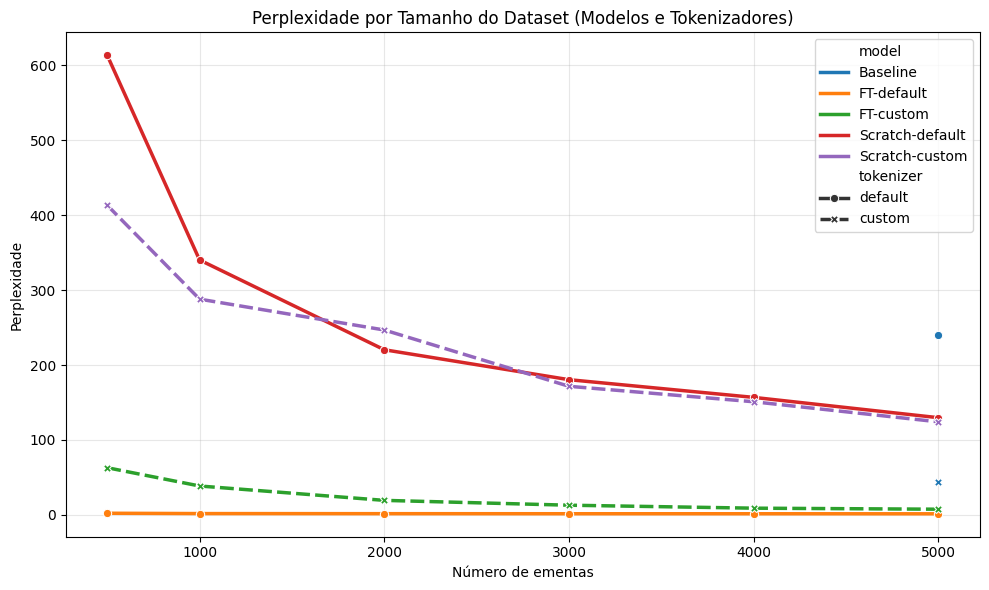

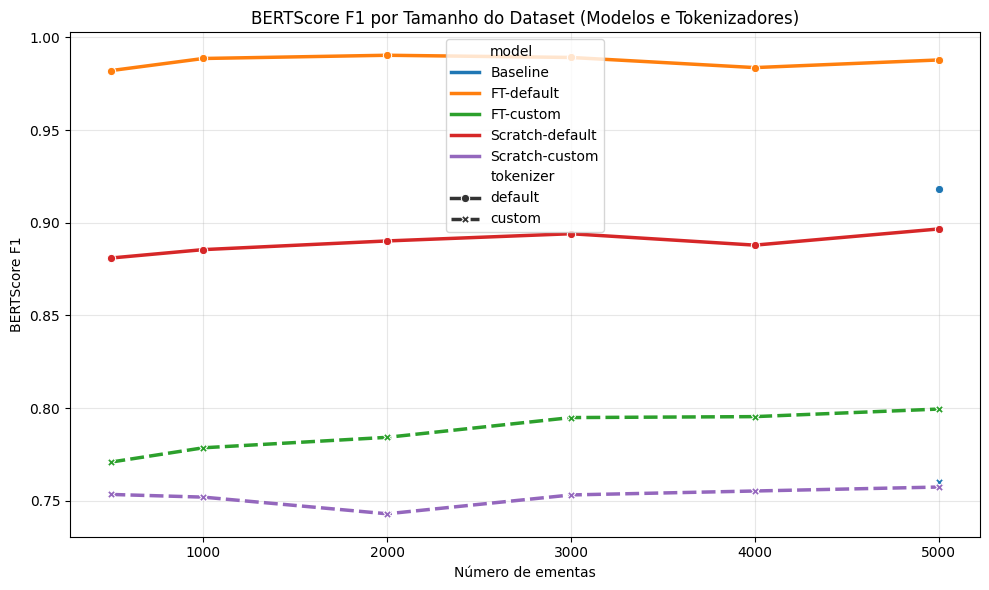

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# df = dataframe carregado com seus resultados

# -------------------------------------------------------------------
# Gráfico 1: Perplexidade vs. Tamanho do Dataset
# -------------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="size",
    y="perplexity",
    hue="model",
    style="tokenizer",
    markers=True,
    linewidth=2.5
)
plt.title("Perplexidade por Tamanho do Dataset (Modelos e Tokenizadores)")
plt.xlabel("Número de ementas")
plt.ylabel("Perplexidade")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

save_path = os.path.join(CONFIG["OUTPUT_DIR"], 'grafico_perplexidade.png')
plt.savefig(save_path, dpi=300)

# -------------------------------------------------------------------
# Gráfico 2: BERTScore F1 vs. Tamanho do Dataset
# -------------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="size",
    y="bertscore_f1",
    hue="model",
    style="tokenizer",
    markers=True,
    linewidth=2.5
)
plt.title("BERTScore F1 por Tamanho do Dataset (Modelos e Tokenizadores)")
plt.xlabel("Número de ementas")
plt.ylabel("BERTScore F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

save_path = os.path.join(CONFIG["OUTPUT_DIR"], 'grafico_bertscore.png')
plt.savefig(save_path, dpi=300)

# -------------------------------------------------------------------
# Gráfico 3: Loss vs. Tamanho do Dataset
# -------------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="size",
    y="loss",
    hue="model",
    style="tokenizer",
    markers=True,
    linewidth=2.5
)
plt.title("Loss por Tamanho do Dataset (Modelos e Tokenizadores)")
plt.xlabel("Número de ementas")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

save_path = os.path.join(CONFIG["OUTPUT_DIR"], 'grafico_loss.png')
plt.savefig(save_path, dpi=300)
